## Use Heart Disease [Dataset](https://github.com/cksajil/DSAIRP25/blob/main/datasets/heart_disease.csv) and answer the following questions

## 1. Find the top 5 important features to the target column

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
df = pd.read_csv('/content/drive/MyDrive/heart_disease.csv')

# Separate features and target
X = df.drop(columns=["target"])
y = df["target"]

# Split data into training and testing sets (optional for feature importance but good practice)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train RandomForestClassifier
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

#Feature importances
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

# Sort and select top 5 features
top_5_features = feature_importance.sort_values(
    by="Importance", ascending=False
).head(5)

print(top_5_features)

    Feature  Importance
2        cp    0.135072
11       ca    0.127327
7   thalach    0.122169
9   oldpeak    0.121905
12     thal    0.110518


## 2. Perform Box-Cox Transformations to relevant features

Highly skewed features (|skewness| > 1):
['chol', 'oldpeak']


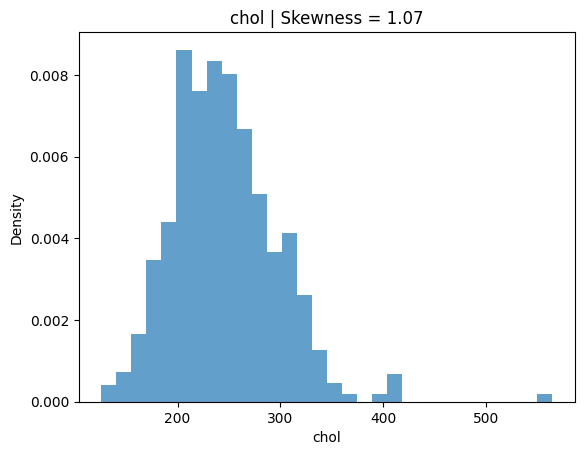

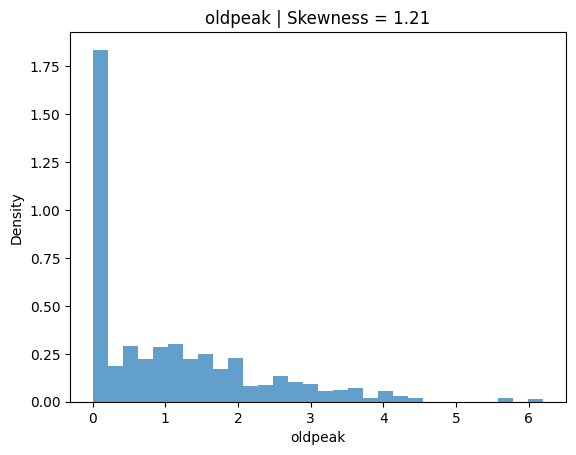

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew

df = pd.read_csv('/content/drive/MyDrive/heart_disease.csv')

target_col = "target"

# Numerical features (exclude target)
num_df = df.drop(columns=[target_col]).select_dtypes(include=[np.number])

# Continuous features only
continuous_features = [
    col for col in num_df.columns if num_df[col].nunique() > 10
]

# Compute skewness
skewness = num_df[continuous_features].apply(skew)

# Filter for highly skewed features
highly_skewed_features = skewness[abs(skewness) > 1].index.tolist()

print("Highly skewed features (|skewness| > 1):")
print(highly_skewed_features)

# Plot only highly skewed features
for col in highly_skewed_features:
    plt.figure()
    plt.hist(num_df[col], bins=30, density=True, alpha=0.7)
    plt.title(f"{col} | Skewness = {skewness[col]:.2f}")
    plt.xlabel(col)
    plt.ylabel("Density")
    plt.show()

In [6]:
import pandas as pd
import numpy as np
from scipy.stats import skew
from sklearn.preprocessing import PowerTransformer

target_col = "target"

# Numerical features (exclude target)
num_df = df.drop(columns=[target_col]).select_dtypes(include=[np.number])

# Continuous features only
continuous_features = [
    col for col in num_df.columns if num_df[col].nunique() > 10
]

# Compute skewness before transformation
skew_before = num_df[continuous_features].apply(skew)

# Select highly skewed features (|skew| > 1)
skewed_features = skew_before[skew_before.abs() > 1].index.tolist()

print("Features selected for Box-Cox:")
print(skewed_features)

# Keep only strictly positive features (Box-Cox requirement)
boxcox_features = [
    col for col in skewed_features if (num_df[col] > 0).all()
]

# Apply Box-Cox
pt = PowerTransformer(method="box-cox")
df_boxcox = num_df.copy()
df_boxcox[boxcox_features] = pt.fit_transform(num_df[boxcox_features])

# Compute skewness after transformation
skew_after = df_boxcox[boxcox_features].apply(skew)

# Compare skewness before vs after
skewness_comparison = pd.DataFrame({
    "Skewness_Before": skew_before[boxcox_features],
    "Skewness_After": skew_after
})

print("\nSkewness comparison (Before vs After Box-Cox):")
print(skewness_comparison)


Features selected for Box-Cox:
['chol', 'oldpeak']

Skewness comparison (Before vs After Box-Cox):
      Skewness_Before  Skewness_After
chol           1.0725       -0.004708


## 3. Perform Feature Binning to Age Column and add it as a new column to the dataset

In [7]:
# Define age bins and labels
bins = [0, 40, 50, 60, 70, 100]
labels = ["<=40", "41-50", "51-60", "61-70", "70+"]

# Create binned age column
df["age_binned"] = pd.cut(
    df["age"],
    bins=bins,
    labels=labels,
    right=True
)

# View result
print(df[["age", "age_binned"]].head())


   age age_binned
0   52      51-60
1   53      51-60
2   70      61-70
3   61      61-70
4   62      61-70


## 4. Find the most orthogonal feature to the 'chol' feature

Using Cosine Similarity Method

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

X = num_df.dropna()

chol_vector = X[["chol"]].values
other_features = X.drop(columns=["chol"])

cos_sim = cosine_similarity(chol_vector.T, other_features.T).flatten()

most_orthogonal_cosine = other_features.columns[np.argmin(np.abs(cos_sim))]

print("Most orthogonal (cosine):", most_orthogonal_cosine)


Most orthogonal (cosine): fbs


Using Correlation Matrix

In [ ]:


# Select numerical features only
num_df = df.select_dtypes(include=[np.number])

# Compute correlation matrix
corr_matrix = num_df.corr()

# Correlation of all features with 'chol' (exclude itself)
chol_corr = corr_matrix["chol"].drop("chol")

# Find most orthogonal feature (minimum absolute correlation)
most_orthogonal_feature = chol_corr.abs().idxmin()
orthogonality_value = chol_corr[most_orthogonal_feature]

print("Most orthogonal feature to 'chol':", most_orthogonal_feature)
print("Correlation value:", orthogonality_value)


Most orthogonal feature to 'chol': slope
Correlation value: -0.014247867919343115


Correlation Heatmap

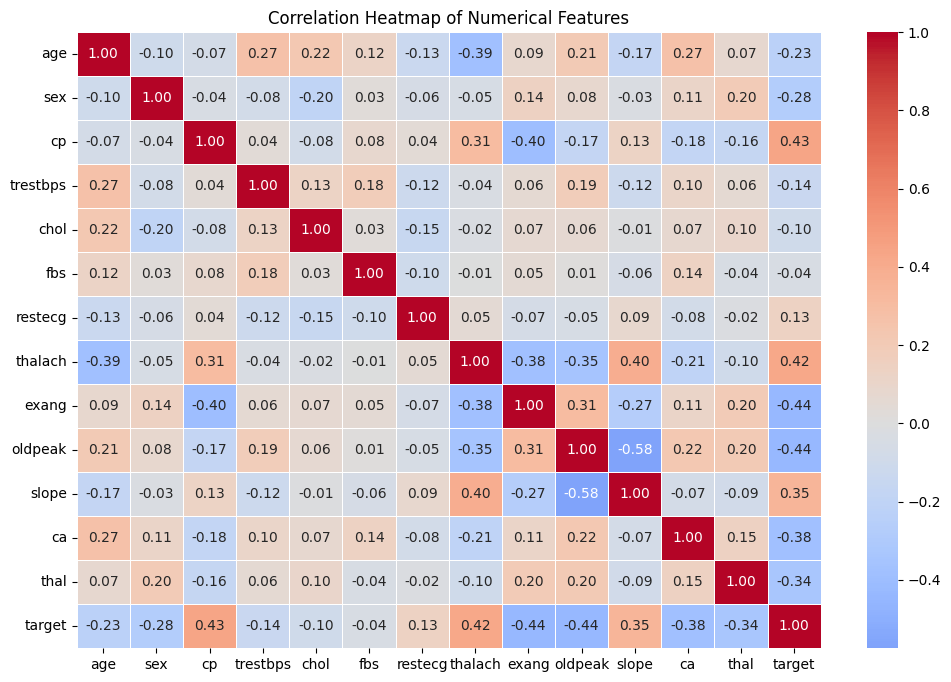

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns


# Select numerical features only
num_df = df.select_dtypes(include=[np.number])

# Compute correlation matrix
corr_matrix = num_df.corr()

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)
plt.title("Correlation Heatmap of Numerical Features")
plt.show()
